In [3]:
import numpy as np
import pandas as pd

In [4]:
df = pd.read_csv('/content/dataset.csv')

In [5]:
df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   383 non-null    int64 
 1   Gender                383 non-null    object
 2   Smoking               383 non-null    object
 3   Hx Smoking            383 non-null    object
 4   Hx Radiothreapy       383 non-null    object
 5   Thyroid Function      383 non-null    object
 6   Physical Examination  383 non-null    object
 7   Adenopathy            383 non-null    object
 8   Pathology             383 non-null    object
 9   Focality              383 non-null    object
 10  Risk                  383 non-null    object
 11  T                     383 non-null    object
 12  N                     383 non-null    object
 13  M                     383 non-null    object
 14  Stage                 383 non-null    object
 15  Response              383 non-null    ob

In [7]:
df.isnull().sum()

,0
Age,0
Gender,0
Smoking,0
Hx Smoking,0
Hx Radiothreapy,0
Thyroid Function,0
Physical Examination,0
Adenopathy,0
Pathology,0
Focality,0


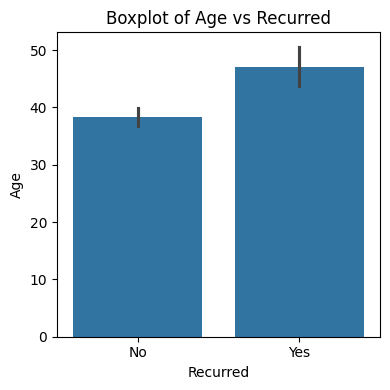

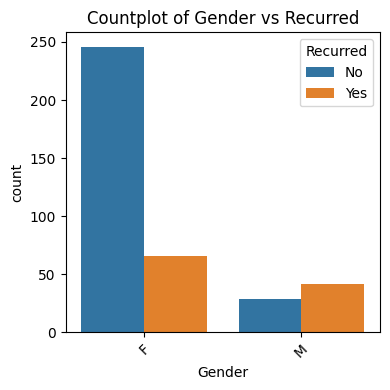

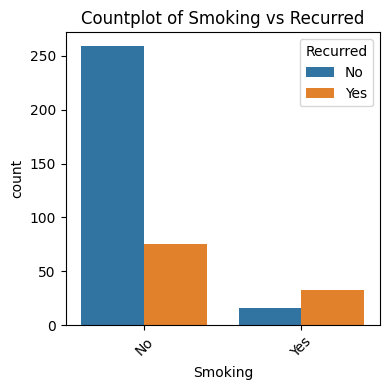

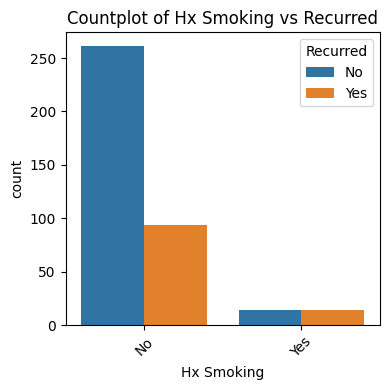

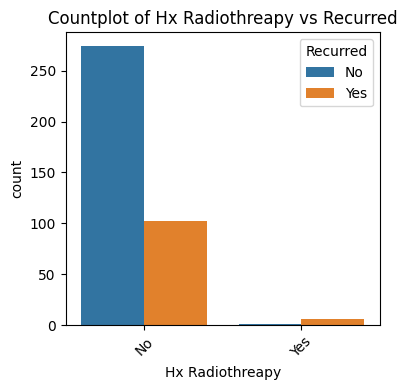

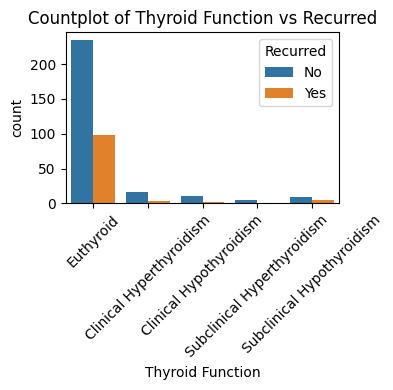

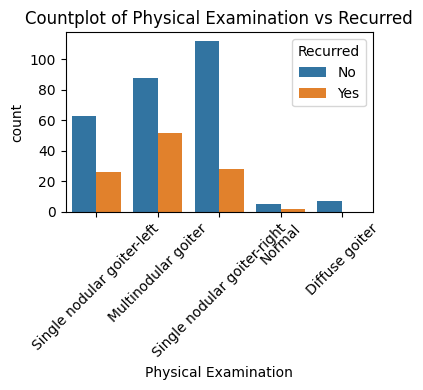

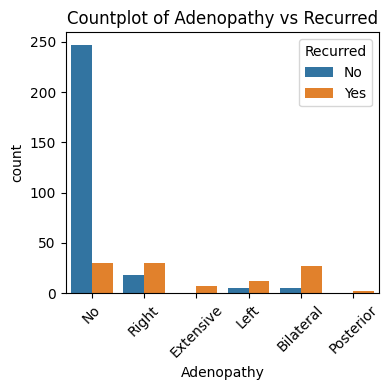

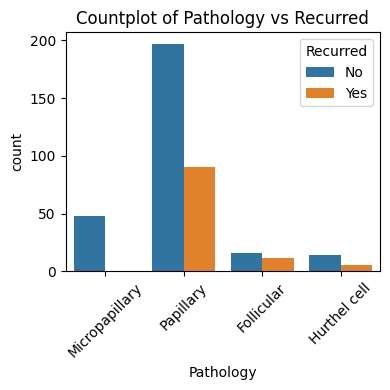

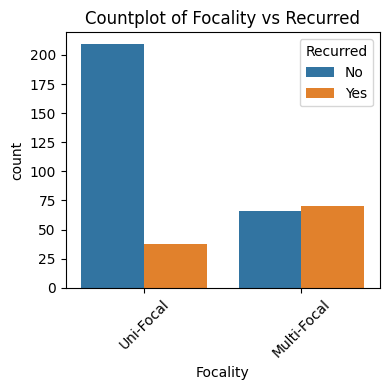

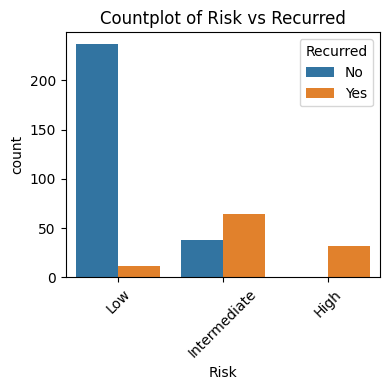

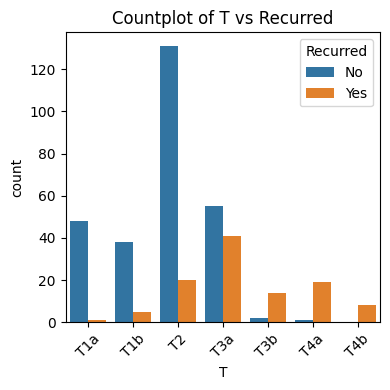

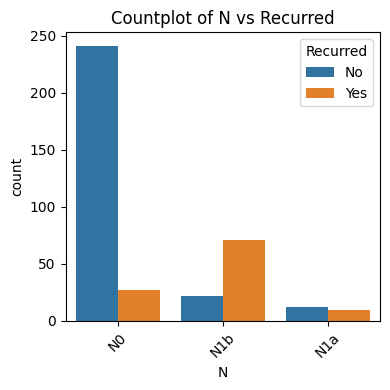

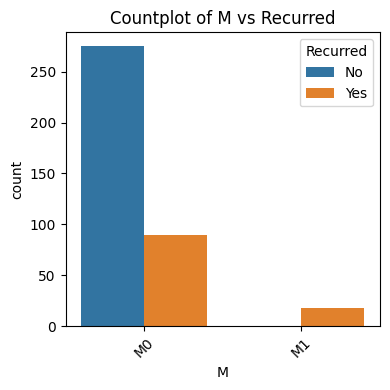

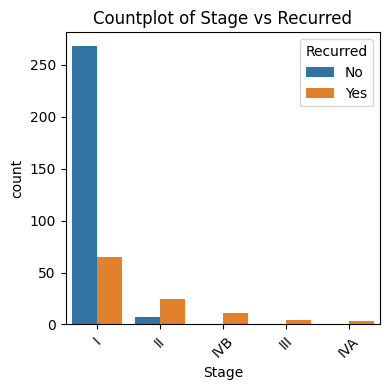

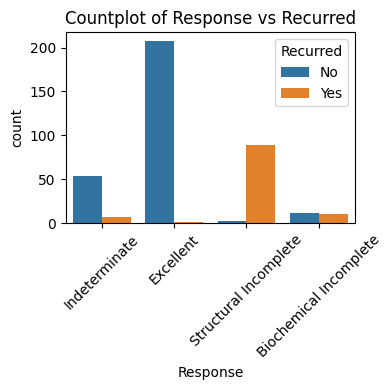

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in df.columns:
    if col == "Recurred":
        continue

    if df[col].dtype == "object":
        plt.figure(figsize=(4, 4))
        sns.countplot(x=col, hue="Recurred", data=df)
        plt.title(f"Countplot of {col} vs Recurred")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        print()

    elif df[col].dtype in ["int64", "float64"]:
        plt.figure(figsize=(4, 4))
        sns.barplot(x="Recurred", y=col, data=df)
        plt.title(f"Boxplot of {col} vs Recurred")
        plt.tight_layout()
        plt.show()
        print()

In [9]:
for col in df.columns:
  print(col, df[col].nunique())
  print(df[col].unique())
  print()

Age 65
[27 34 30 62 52 41 46 51 40 75 59 49 50 76 42 44 43 36 70 60 33 26 37 55
 31 45 20 38 29 25 21 23 24 35 54 22 69 28 17 73 18 39 57 66 32 47 56 63
 19 67 72 61 68 48 81 53 58 80 79 65 15 82 71 64 78]

Gender 2
['F' 'M']

Smoking 2
['No' 'Yes']

Hx Smoking 2
['No' 'Yes']

Hx Radiothreapy 2
['No' 'Yes']

Thyroid Function 5
['Euthyroid' 'Clinical Hyperthyroidism' 'Clinical Hypothyroidism'
 'Subclinical Hyperthyroidism' 'Subclinical Hypothyroidism']

Physical Examination 5
['Single nodular goiter-left' 'Multinodular goiter'
 'Single nodular goiter-right' 'Normal' 'Diffuse goiter']

Adenopathy 6
['No' 'Right' 'Extensive' 'Left' 'Bilateral' 'Posterior']

Pathology 4
['Micropapillary' 'Papillary' 'Follicular' 'Hurthel cell']

Focality 2
['Uni-Focal' 'Multi-Focal']

Risk 3
['Low' 'Intermediate' 'High']

T 7
['T1a' 'T1b' 'T2' 'T3a' 'T3b' 'T4a' 'T4b']

N 3
['N0' 'N1b' 'N1a']

M 2
['M0' 'M1']

Stage 5
['I' 'II' 'IVB' 'III' 'IVA']

Response 4
['Indeterminate' 'Excellent' 'Structural Incomple

In [10]:
df.shape

(383, 17)

In [11]:
df.columns

Index(['Age', 'Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy',
       'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology',
       'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Recurred'],
      dtype='object')

In [12]:
from sklearn.preprocessing import LabelEncoder

cols = ['Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy',
       'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology',
       'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Recurred']

for col in cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

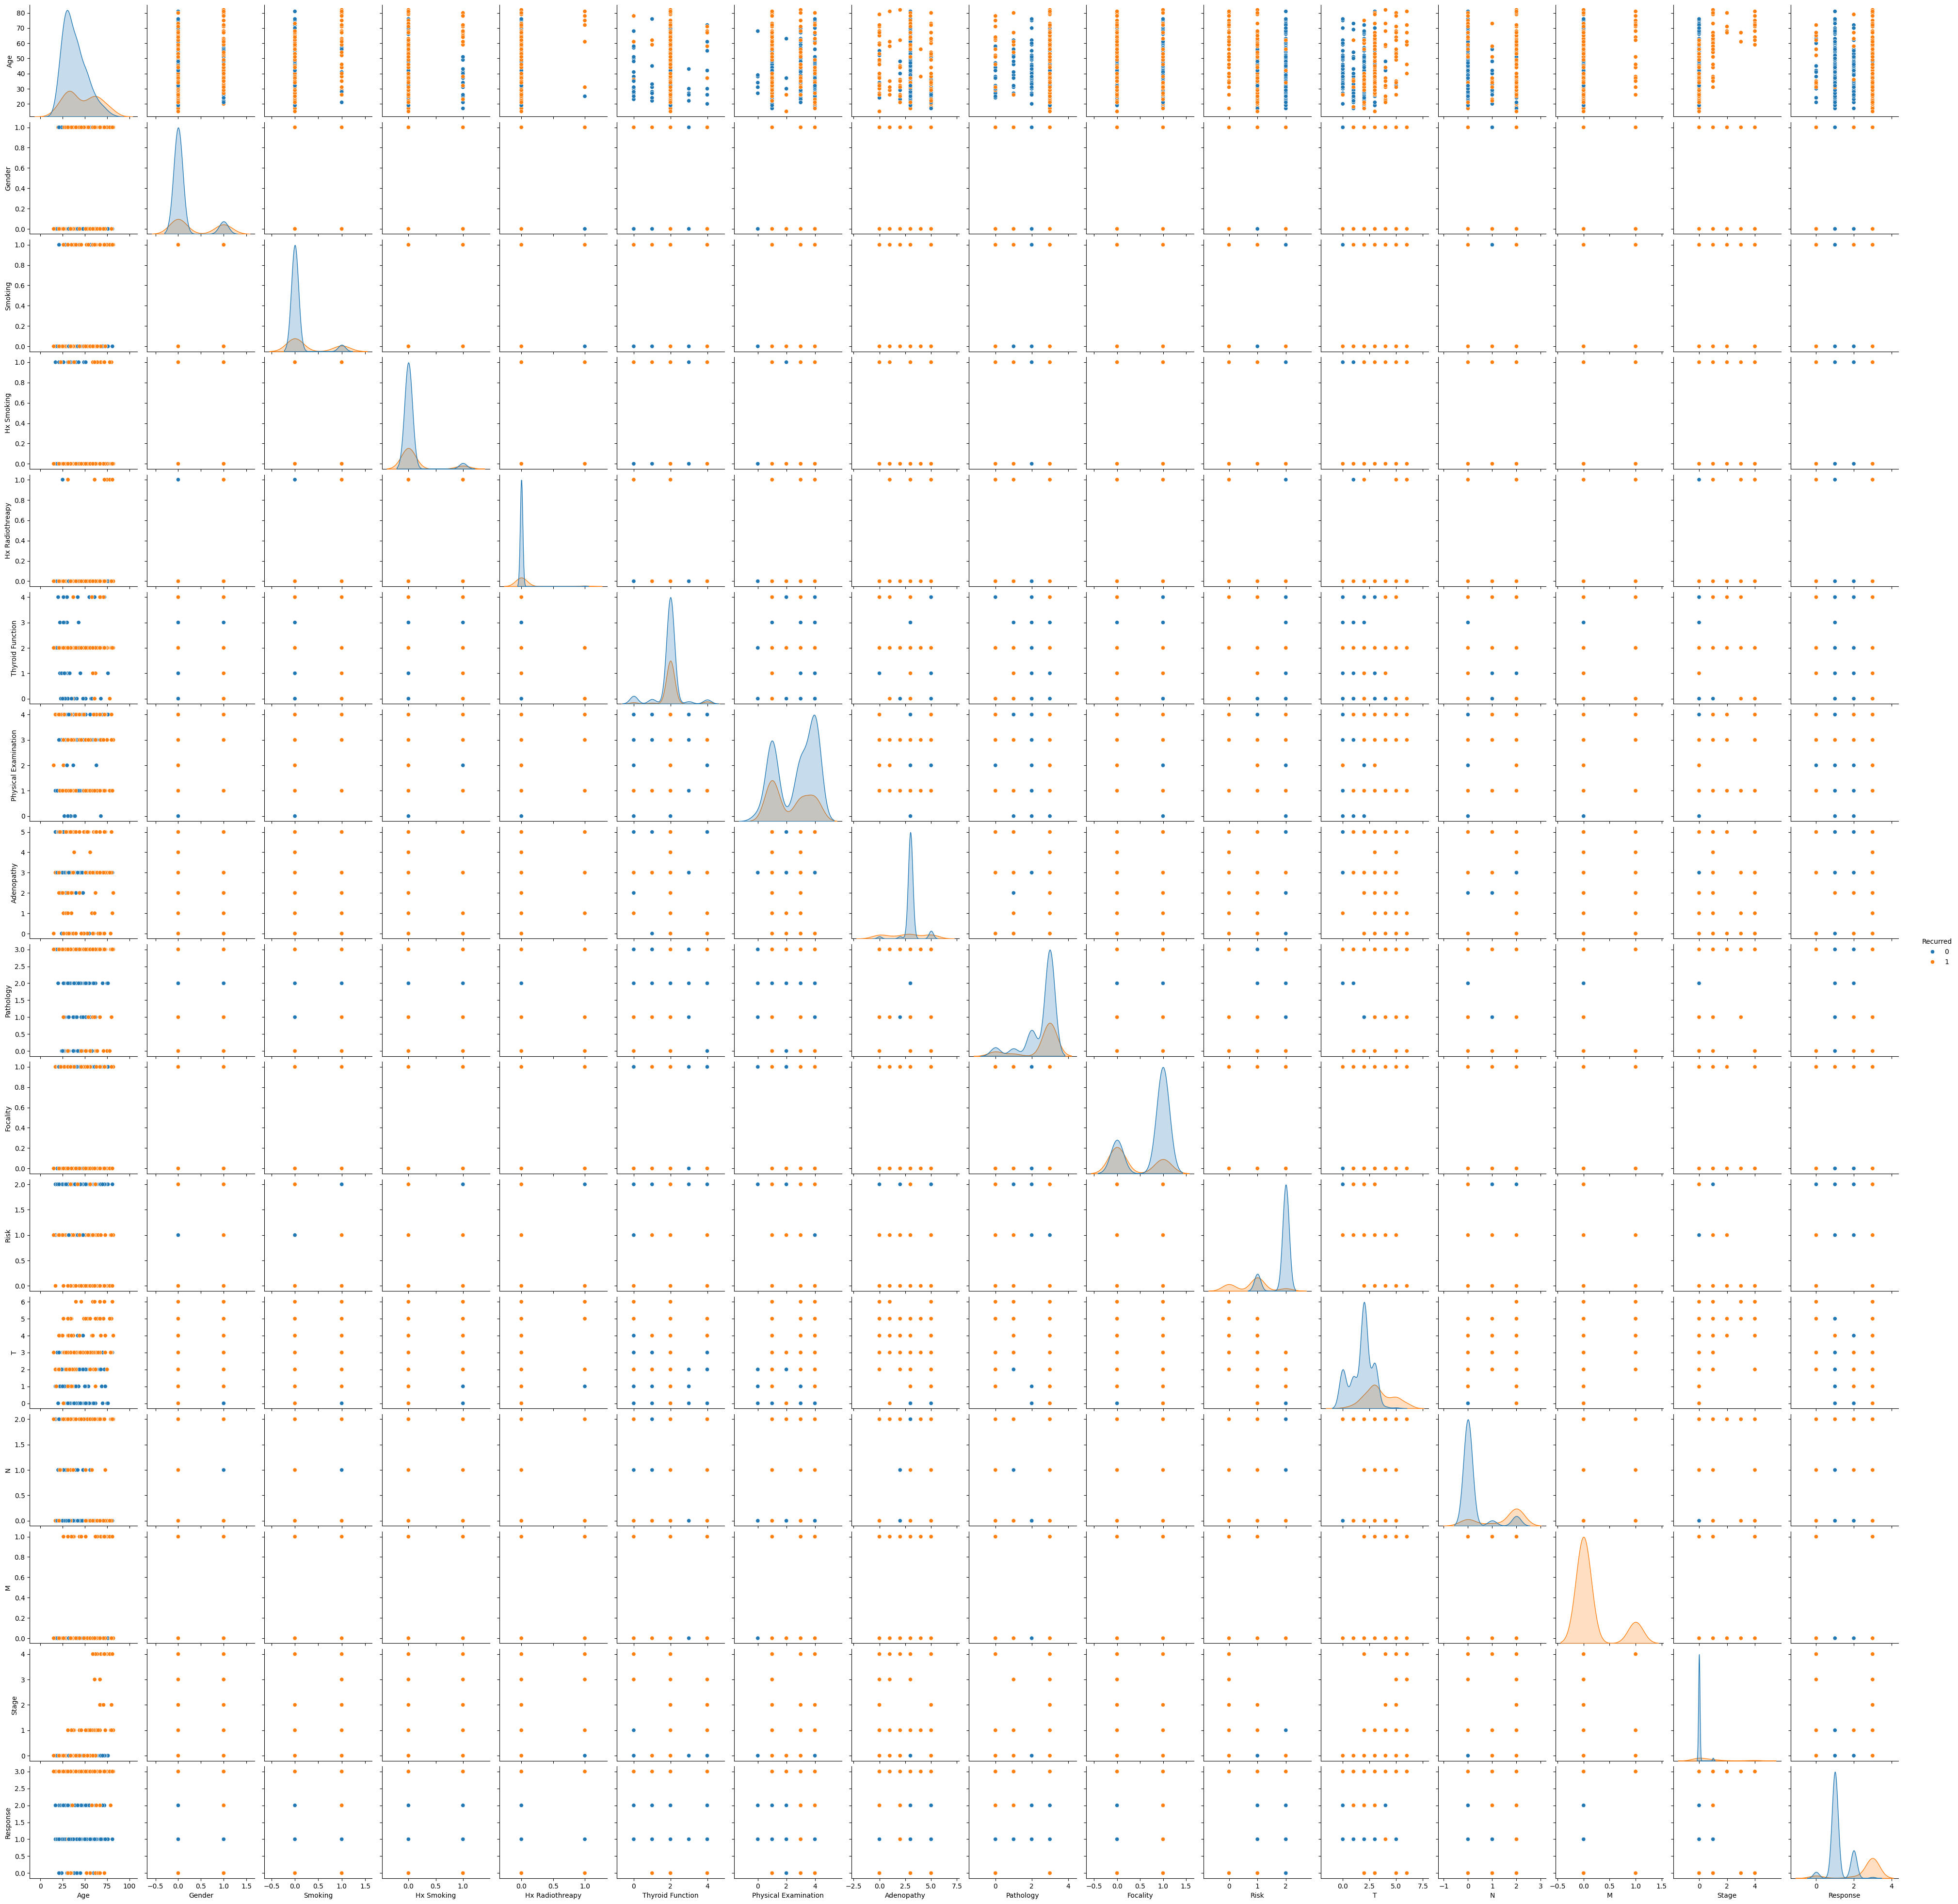

In [13]:
selected_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Add the target column if not numeric
if 'Recurred' not in selected_cols:
    selected_cols.append('Recurred')

sns.pairplot(df[selected_cols], hue='Recurred')
plt.show()

In [14]:
df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,0,0,0,0,2,3,3,2,1,2,0,0,0,0,2,0
1,34,0,0,1,0,2,1,3,2,1,2,0,0,0,0,1,0
2,30,0,0,0,0,2,4,3,2,1,2,0,0,0,0,1,0
3,62,0,0,0,0,2,4,3,2,1,2,0,0,0,0,1,0
4,62,0,0,0,0,2,1,3,2,0,2,0,0,0,0,1,0


In [15]:
X = df.drop('Recurred', axis=1)
y = df['Recurred']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
X_train

array([[-0.08221572, -0.51933568, -0.40434898, ..., -0.21063855,
        -0.32628   , -0.63689373],
       [ 1.36289187, -0.51933568, -0.40434898, ..., -0.21063855,
         1.04141424,  1.51658121],
       [-0.80476951, -0.51933568, -0.40434898, ..., -0.21063855,
        -0.32628   ,  0.43984374],
       ...,
       [-0.14790243, -0.51933568, -0.40434898, ..., -0.21063855,
        -0.32628   ,  0.43984374],
       [ 1.10014504, -0.51933568, -0.40434898, ..., -0.21063855,
         1.04141424,  1.51658121],
       [-0.93614293, -0.51933568, -0.40434898, ..., -0.21063855,
        -0.32628   , -0.63689373]])

<Axes: >

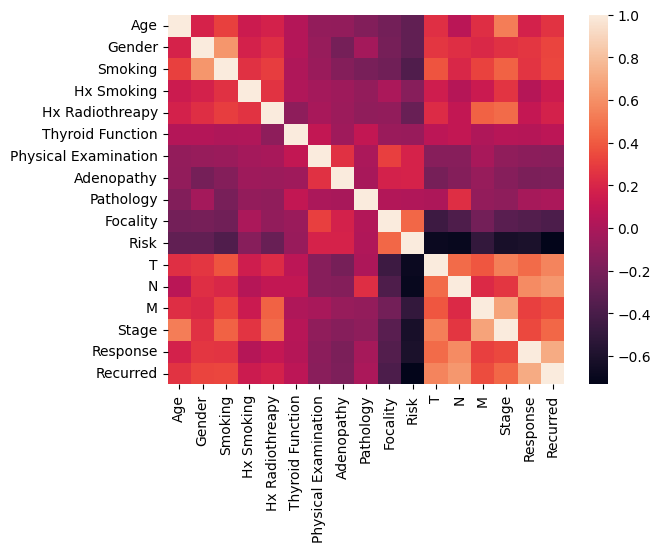

In [21]:
sns.heatmap(df.corr(), annot=False)

In [24]:
import xgboost as xgb

model = xgb.XGBClassifier()
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [25]:
predictions = model.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, predictions))
print("\nClassification Report:\n", classification_report(y_test, predictions))

Accuracy: 0.961038961038961

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.97        58
           1       0.90      0.95      0.92        19

    accuracy                           0.96        77
   macro avg       0.94      0.96      0.95        77
weighted avg       0.96      0.96      0.96        77



In [31]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

param_grid = {
    'n_estimators': [50, 100, 150,200,250],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0]
}

# Grid search setup
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

# Run grid search
grid_search.fit(X_train, y_train)

# Best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy Score:", grid_search.best_score_)

Fitting 5 folds for each of 135 candidates, totalling 675 fits
Best Parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 250, 'subsample': 1.0}
Best Accuracy Score: 0.9575356953992598


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [17:15:05] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))

Random Forest Accuracy: 0.974025974025974


In [33]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)
ada_preds = ada.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, ada_preds))

AdaBoost Accuracy: 0.961038961038961


In [34]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
gb_preds = gb.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_preds))

Gradient Boosting Accuracy: 0.974025974025974


In [35]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_preds))

XGBoost Accuracy: 0.961038961038961


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [17:16:36] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [36]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

log_clf = LogisticRegression(max_iter=1000)
svc_clf = SVC(probability=True)

voting = VotingClassifier(estimators=[
    ('lr', log_clf),
    ('rf', rf),
    ('xgb', xgb)
], voting='soft')  # Change to 'hard' for hard voting

voting.fit(X_train, y_train)
voting_preds = voting.predict(X_test)

print("Voting Classifier Accuracy:", accuracy_score(y_test, voting_preds))

Voting Classifier Accuracy: 0.961038961038961


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [17:16:42] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [37]:
from sklearn.ensemble import StackingClassifier

estimators = [
    ('rf', rf),
    ('ada', ada),
    ('gb', gb)
]

final_estimator = LogisticRegression(max_iter=1000)

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=5
)

stacking.fit(X_train, y_train)
stack_preds = stacking.predict(X_test)

print("Stacking Classifier Accuracy:", accuracy_score(y_test, stack_preds))

Stacking Classifier Accuracy: 0.974025974025974


In [39]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

rf_preds = best_model.predict(X_test)
print("Tuned RF Accuracy:", accuracy_score(y_test, rf_preds))


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Tuned RF Accuracy: 0.987012987012987


In [40]:
print(best_model.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [41]:
final_model = RandomForestClassifier(
    bootstrap=True,
    ccp_alpha=0.0,
    class_weight=None,
    criterion='gini',
    max_depth=None,
    max_features='sqrt',
    max_leaf_nodes=None,
    max_samples=None,
    min_impurity_decrease=0.0,
    min_samples_leaf=2,
    min_samples_split=5,
    min_weight_fraction_leaf=0.0,
    n_estimators=100,
    n_jobs=None,
    oob_score=False,
    random_state=42,
    verbose=0,
    warm_start=False
)

# Train the model
final_model.fit(X_train, y_train)

# Predict
rf_preds = final_model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, rf_preds))
print("\nClassification Report:\n", classification_report(y_test, rf_preds))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_preds))


Accuracy: 0.987012987012987

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99        58
           1       1.00      0.95      0.97        19

    accuracy                           0.99        77
   macro avg       0.99      0.97      0.98        77
weighted avg       0.99      0.99      0.99        77


Confusion Matrix:
 [[58  0]
 [ 1 18]]
